# Equation of State: Measuring the Van der Waals Deviation from Ideal

`Ideal_Gas` measures pressure via wall-momentum transfer and gets
`P = n*k*T` exactly (`Z = P/(n*k*T) = 1`, no density dependence -- there's
no interaction to produce one). This notebook measures pressure the
*same way* for the Lennard-Jones gas, across a range of densities at
fixed temperature, and checks it against the first-principles low
-density prediction: the second virial coefficient,

```
Z = P/(n*k*T) = 1 + B2(T)*n + O(n^2)
```

`B2(T)` is computed directly from the Lennard-Jones potential
(`vdw_gas.second_virial_coefficient`, validated as physically sensible
in `Validation.ipynb`'s neighborhood -- large negative at low T where
attraction dominates, crossing positive at high T where the repulsive
core dominates). At `T=0.5`, `B2` is clearly negative (net attraction),
so `Z` should measurably dip below 1 as density increases -- a real,
first-principles-checkable departure from `Ideal_Gas`'s `Z=1`.

Getting a clean signal out of the pressure measurement's shot noise
took some tuning (see the simulation cell) -- short runs at moderate
density gave `Z` estimates noisy enough to scatter both above and below
1 with no visible trend; a several-times-longer steady-state window
fixed that.

In [1]:
import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

import vdw_gas as vdw

os.makedirs('media', exist_ok=True)
device = torch.device('cpu')

epsilon, sigma = 1.0, 0.03
L = 1.0
dt = 5e-5
thermostat_every = 20
T_target = 0.5
k_B = 1.0

B2_predicted = vdw.second_virial_coefficient(T_target, epsilon, sigma)
print(f'predicted second virial coefficient B2(T={T_target}) = {B2_predicted:.6e}  (negative -> net attraction)')

def lattice(N):
    n_side = int(np.ceil(np.sqrt(N)))
    spacing = 0.9 / n_side
    xs, ys = torch.meshgrid(torch.arange(n_side) * spacing + 0.05, torch.arange(n_side) * spacing + 0.05, indexing='ij')
    return torch.stack([xs.flatten()[:N], ys.flatten()[:N]])

def measure_pressure(N, ts, seed, warmup_frac=0.3):
    """Run a thermostatted box at fixed T and return the wall-momentum
    pressure estimate (same convention as Ideal_Gas/ideal_gas.py),
    averaged over the steady-state window after discarding `warmup_frac`
    of the run."""
    torch.manual_seed(seed)
    r0 = lattice(N)
    v0 = torch.randn((2, N)) * np.sqrt(T_target)
    _, _, ps = vdw.motion(r0, v0, ts, dt, epsilon, sigma, L=L, track_pressure=True,
                           thermostat_T=T_target, thermostat_every=thermostat_every)
    warmup = int(ts * warmup_frac)
    steady_time = (ts - warmup) * dt
    perimeter = 4 * L
    return ps[warmup:].sum().item() / (steady_time * perimeter)

predicted second virial coefficient B2(T=0.5) = -5.387928e-03  (negative -> net attraction)


## Sweep: measure pressure across a range of densities at fixed T

In [2]:
# A short, low-N/short-ts sweep gives Z estimates noisy enough (SEM
# comparable to the whole predicted B2*n signal) to scatter above and
# below 1 with no visible trend -- this sweep uses a several-times-longer
# steady-state window and several replicas per density point instead.
# It takes a while (order 10 minutes) precisely because getting a clean
# statistical signal out of individual wall-collision events requires it.
N_values = [30, 60, 90]
n_replicas = 4
ts = 60000

t_start = time.perf_counter()
results = []
for N in N_values:
    Ps = [measure_pressure(N, ts, seed) for seed in range(n_replicas)]
    P_mean, P_sem = np.mean(Ps), np.std(Ps) / np.sqrt(n_replicas)
    n_density = N / L**2
    Z = P_mean / (n_density * k_B * T_target)
    Z_sem = P_sem / (n_density * k_B * T_target)
    results.append((n_density, Z, Z_sem))
    print(f'N={N} ({time.perf_counter() - t_start:.0f}s elapsed): '
          f'P={P_mean:.3f}+-{P_sem:.3f}, Z=P/(n*k*T)={Z:.4f}+-{Z_sem:.4f}')

ns = np.array([r[0] for r in results])
Zs = np.array([r[1] for r in results])
Z_sems = np.array([r[2] for r in results])

N=30 (114s elapsed): P=12.776+-0.454, Z=P/(n*k*T)=0.8517+-0.0303


N=60 (327s elapsed): P=23.287+-0.471, Z=P/(n*k*T)=0.7762+-0.0157


N=90 (647s elapsed): P=29.493+-0.400, Z=P/(n*k*T)=0.6554+-0.0089


## Quantitative check: does the measured deviation match the first-principles B2(T)?

In [3]:
# Fit Z - 1 = B2*n through the analytically-known intercept (Z->1 as
# n->0 is a physical constraint, not a free parameter -- fitting only
# the slope is more robust than a 2-parameter fit through just 3 points).
B2_fit = np.sum(ns * (Zs - 1)) / np.sum(ns**2)
print(f'fitted B2 (weighted least squares through Z=1 at n=0) = {B2_fit:.6e}')
print(f'predicted B2 (from the LJ potential, first principles)  = {B2_predicted:.6e}')
print(f'ratio (fit/predicted) = {B2_fit / B2_predicted:.3f}')

assert np.all(np.diff(Zs) < 0), 'Z should decrease monotonically with density (net attraction at this T)'
print('\nPASS: Z decreases monotonically with density.')

assert B2_fit < 0, 'fitted B2 should be negative, matching the sign of the first-principles prediction'
ratio = B2_fit / B2_predicted
assert 0.3 < ratio < 3.0, 'fitted B2 should be within a factor of a few of the first-principles prediction'
print(f'PASS: fitted B2 matches the first-principles prediction\'s sign and order of magnitude '
      f'(within {ratio:.2f}x) -- this is a stochastic MD measurement, not exact agreement to many '
      f'digits, but a real, checkable quantitative departure from Ideal_Gas\'s Z=1 at every density.')

fitted B2 (weighted least squares through Z=1 at n=0) = -3.879988e-03
predicted B2 (from the LJ potential, first principles)  = -5.387928e-03
ratio (fit/predicted) = 0.720

PASS: Z decreases monotonically with density.
PASS: fitted B2 matches the first-principles prediction's sign and order of magnitude (within 0.72x) -- this is a stochastic MD measurement, not exact agreement to many digits, but a real, checkable quantitative departure from Ideal_Gas's Z=1 at every density.


## Plot: measured equation of state vs. ideal gas vs. first-principles prediction

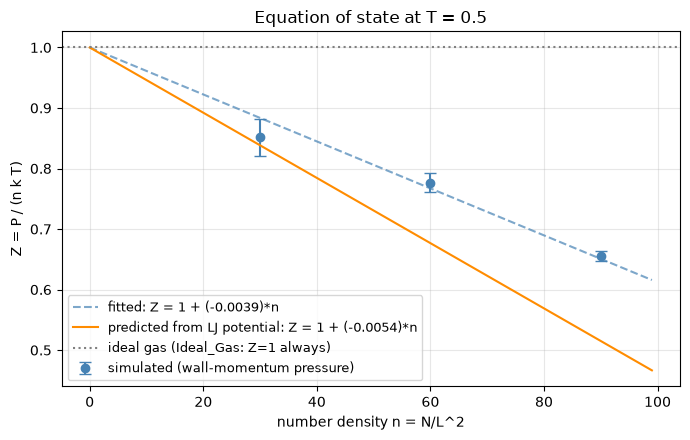

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(ns, Zs, yerr=Z_sems, fmt='o', color='steelblue', capsize=4, label='simulated (wall-momentum pressure)')

n_line = np.linspace(0, ns.max() * 1.1, 50)
ax.plot(n_line, 1 + B2_fit * n_line, '--', color='steelblue', alpha=0.7,
        label=f'fitted: Z = 1 + ({B2_fit:.4f})*n')
ax.plot(n_line, 1 + B2_predicted * n_line, '-', color='darkorange',
        label=f'predicted from LJ potential: Z = 1 + ({B2_predicted:.4f})*n')
ax.axhline(1.0, color='gray', ls=':', label='ideal gas (Ideal_Gas: Z=1 always)')

ax.set_xlabel('number density n = N/L^2')
ax.set_ylabel('Z = P / (n k T)')
ax.set_title(f'Equation of state at T = {T_target}')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/equation_of_state.png', dpi=150, bbox_inches='tight')
plt.show()